In [65]:
#pip install factor_analyzer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo


In [66]:
data = pd.read_csv("C:\\Users\\Nada\\Downloads\\final_project multivarite\\heart.csv")
print(data.head())
print(data.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0      1.0      168      0      1.0      2   
1   53    1   0       140   203    1      0.0      155      1      3.1      0   
2   70    1   0       145   174    0      1.0      125      1      2.6      0   
3   61    1   0       148   203    0      1.0      161      0      0.0      2   
4   62    0   0       138   294    1      1.0      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)


In [67]:
data.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64

In [68]:
data.dropna(inplace=True)
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [69]:
data.duplicated().sum()

720

In [70]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

0

In [71]:
data.shape

(302, 14)

In [72]:
X = data.drop('target', axis=1)

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994


Bartlett’s Test

In [74]:
chi2, p = calculate_bartlett_sphericity(X_scaled)
print(f"Bartlett's test p-value = {p:.6f}") 

Bartlett's test p-value = 0.000000


KMO

In [83]:
kmo_all, kmo_model = calculate_kmo(X_scaled)
print('KMO Score:', kmo_model) 

KMO Score: 0.6662461379028614


Scree Plot

In [76]:
fa = FactorAnalyzer(rotation=None , method='ml')
fa.fit(X_scaled)

ev, v = fa.get_eigenvalues()

C:\Users\Nada\AppData\Local\Temp\ipykernel_19292\3739427254.py:9: UserWarning: Glyph 127872 (\N{RIBBON}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Nada\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127872 (\N{RIBBON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


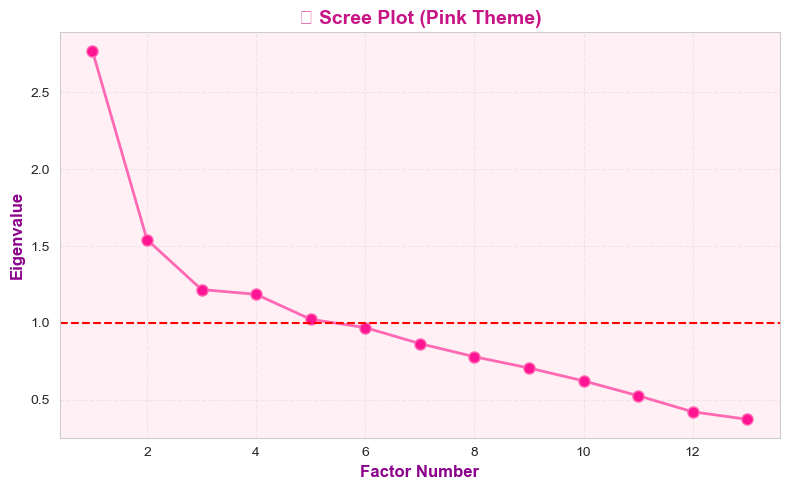

In [77]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(ev)+1), ev, 'o-', color='#FF69B4', linewidth=2, markersize=8, markerfacecolor='#FF1493')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Eigenvalue = 1')
plt.title('🎀 Scree Plot (Pink Theme)', fontsize=14, fontweight='bold', color='#C71585')
plt.xlabel('Factor Number', fontsize=12, fontweight='bold', color='#8B008B')
plt.ylabel('Eigenvalue', fontsize=12, fontweight='bold', color='#8B008B')
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#FFF0F5') 
plt.tight_layout()
plt.show()

In [78]:
n_factors = 5
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='ml')
fa.fit(X_scaled)

FactorAnalyzer(method='ml', n_factors=5, rotation='varimax', rotation_kwargs={})

In [79]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=[f'Factor_{i+1}' for i in range(n_factors)]
)

print("\nFactor Loadings (after Varimax rotation):\n")
print(loadings.round(3))


Factor Loadings (after Varimax rotation):

          Factor_1  Factor_2  Factor_3  Factor_4  Factor_5
age          0.094    -0.117     0.046    -0.325     0.617
sex          0.026     0.988     0.132     0.012     0.026
cp          -0.024     0.045    -0.736     0.102     0.029
trestbps     0.157    -0.068    -0.045     0.025     0.425
chol        -0.013    -0.224     0.132     0.059     0.306
fbs         -0.012     0.053    -0.098    -0.011     0.263
restecg     -0.017    -0.045    -0.071    -0.005    -0.222
thalach     -0.268    -0.013    -0.268     0.917    -0.099
exang        0.215     0.075     0.496    -0.199     0.033
oldpeak      0.878     0.049     0.175    -0.046     0.170
slope       -0.611    -0.004    -0.108     0.202    -0.063
ca           0.123     0.071     0.235    -0.102     0.380
thal         0.150     0.170     0.268     0.035     0.132


In [80]:
for factor in loadings.columns:
    print(f"\n{factor}:")
    high_loadings = loadings[factor][abs(loadings[factor]) > 0.4]
    print(high_loadings.sort_values(ascending=False))


Factor_1:
oldpeak    0.878445
slope     -0.611359
Name: Factor_1, dtype: float64

Factor_2:
sex    0.987909
Name: Factor_2, dtype: float64

Factor_3:
exang    0.496167
cp      -0.735591
Name: Factor_3, dtype: float64

Factor_4:
thalach    0.917238
Name: Factor_4, dtype: float64

Factor_5:
age         0.617204
trestbps    0.424511
Name: Factor_5, dtype: float64


In [81]:
factor_scores = fa.transform(X_scaled)
factor_scores = pd.DataFrame(factor_scores, columns=[f'F{i+1}' for i in range(n_factors)])

factor_scores['target'] = data.loc[X.index, 'target'].values

print(factor_scores.head())

         F1        F2        F3        F4        F5  target
0 -0.289156  0.596611  0.655570  0.988999  0.006977       0
1  1.733113  0.528278  0.749708  1.001067  0.175924       0
2  1.312408  0.555283  0.711027 -0.536974  0.374027       0
3 -1.051871  0.632203  0.474702  0.435000  0.507786       0
4  0.518064 -1.535443  0.347809 -1.744382  0.825398       0


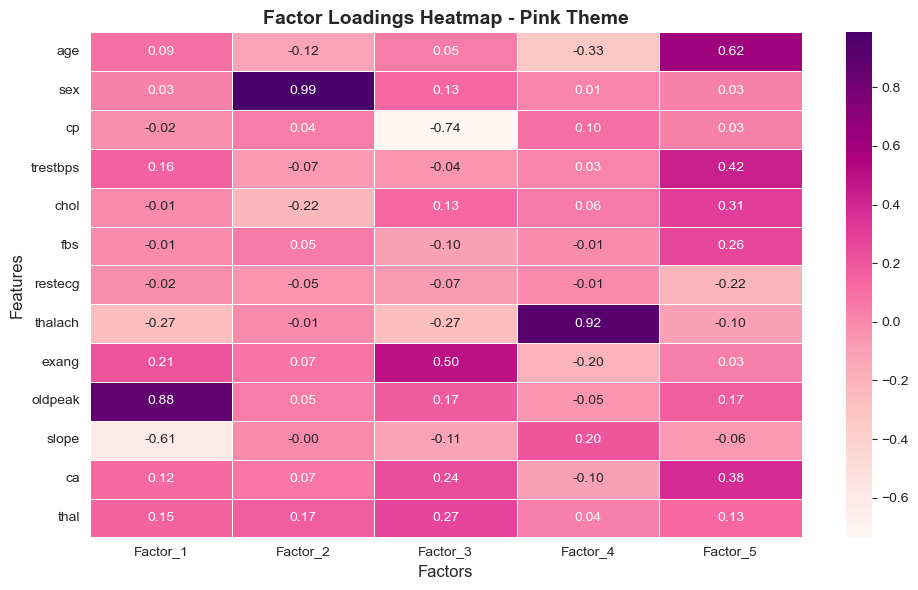

In [82]:
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap='RdPu', fmt='.2f', linewidths=0.5)
plt.title('Factor Loadings Heatmap - Pink Theme', fontsize=14, fontweight='bold')
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()